In [ ]:
#todos los imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


## Matriz de correlación
Antes de aplicar PCA, es útil observar la matriz de correlación para identificar relaciones entre variables y justificar la reducción de dimensionalidad.

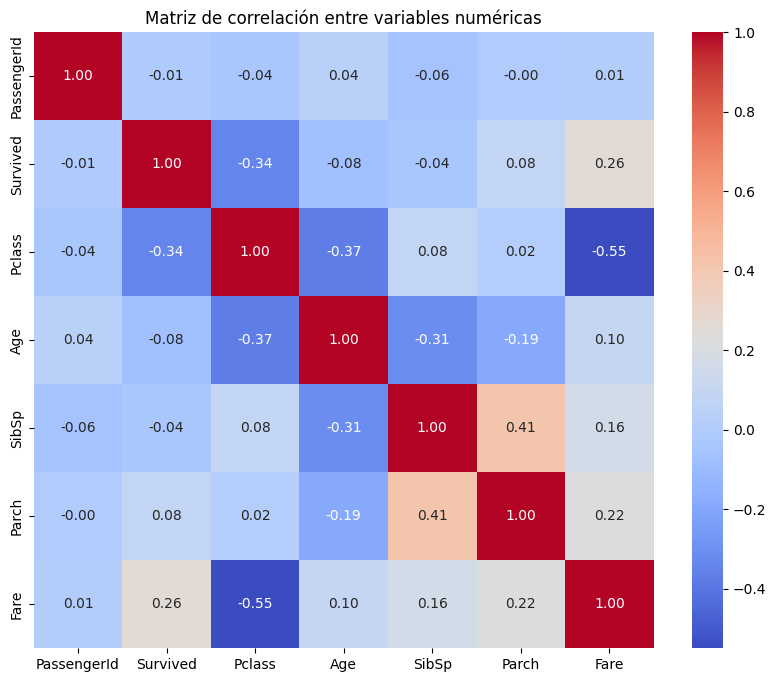

In [18]:
# Seleccionar solo las columnas numéricas
df_num = df.select_dtypes(include=['number'])

# Calcular la matriz de correlación solo con variables numéricas
corr = df_num.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

In [ ]:
df = pd.read_csv("Titanic.csv") # Cargar el dataset

print("Dimensiones del dataset:", df.shape) 
df.head()


print("Columnas del dataset:")
print(df.columns)
print("\nTipos de datos:")
print(df.dtypes)



Dimensiones del dataset: (891, 12)
Columnas del dataset:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Tipos de datos:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


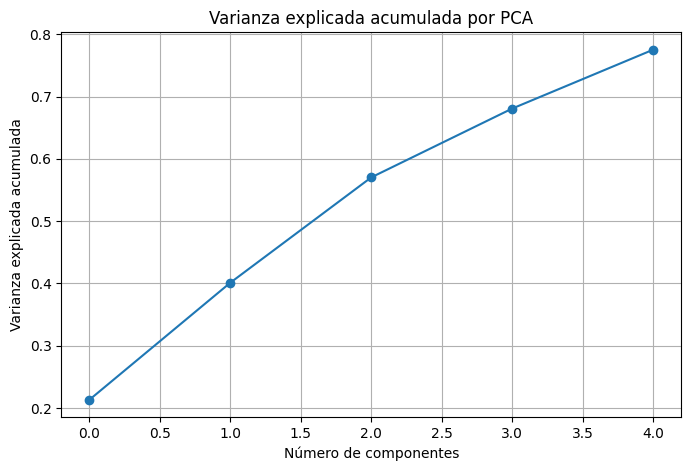

In [20]:
# Gráfica de varianza explicada acumulada
import numpy as np
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada por PCA')
plt.grid(True)
plt.show()

## Varianza explicada acumulada
La gráfica de varianza explicada acumulada permite decidir cuántos componentes principales son necesarios para representar la mayor parte de la información del dataset.

In [21]:
# Quitamos texto irrelevante y la columna objetivo
cols_to_drop = ["Name", "Ticket", "Cabin"]  # texto libre
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Separar variable objetivo (no se normaliza porque no participa del PCA)
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Convertir categóricas a numéricas (evita sesgo)
X = pd.get_dummies(X, drop_first=True)

# Reemplazar valores faltantes
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

print("Forma final de X (despues de limpiar):", X.shape)
X.head()


Forma final de X (despues de limpiar): (891, 9)


,PassengerId,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,3,22.0,1,0,7.2500,True,False,True
1,2,1,38.0,1,0,71.2833,False,False,False
2,3,3,26.0,0,0,7.9250,False,False,True
3,4,1,35.0,1,0,53.1000,False,False,True
4,5,3,35.0,0,0,8.0500,True,False,True


In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Escalado exitoso. Forma de X_scaled:", X_scaled.shape)


Escalado exitoso. Forma de X_scaled: (891, 9)


In [23]:
pca = PCA(n_components=5)  # 5 componentes para analizar
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
varianza = pca.explained_variance_ratio_
print("Varianza explicada por PC1:", round(varianza[0]*100,2), "%")
print("Varianza explicada por PC2:", round(varianza[1]*100,2), "%")
print("Varianza total (PC1+PC2):", round((varianza[0]+varianza[1])*100,2), "%")


Varianza explicada por PC1: 21.33 %
Varianza explicada por PC2: 18.79 %
Varianza total (PC1+PC2): 40.12 %


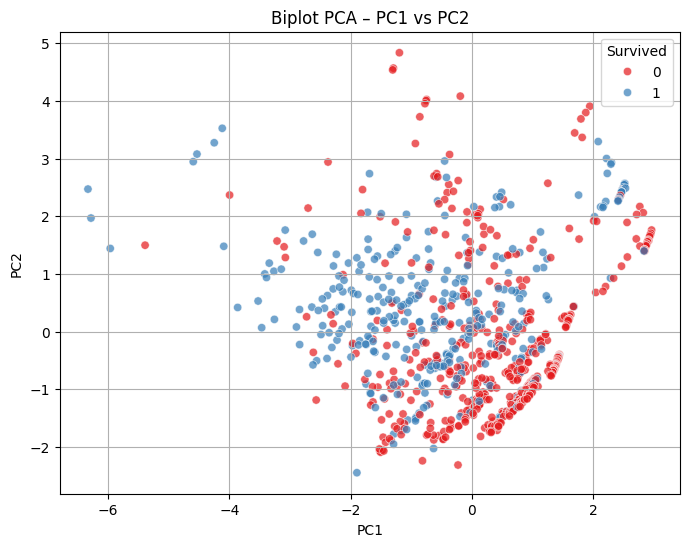

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette="Set1", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biplot PCA – PC1 vs PC2")
plt.legend(title="Survived")
plt.grid(True)
plt.show()


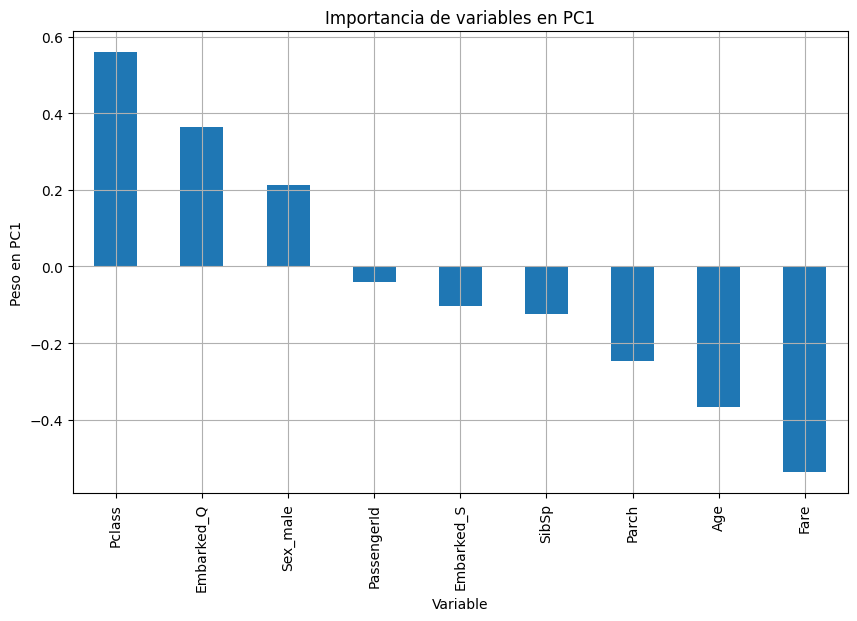

In [25]:
# Gráfica de importancia de variables en PC1
pc1_importancia = pd.Series(pca.components_[0], index=X.columns).sort_values(ascending=False)
pc1_importancia.plot(kind='bar', figsize=(10,6))
plt.title('Importancia de variables en PC1')
plt.ylabel('Peso en PC1')
plt.xlabel('Variable')
plt.grid(True)
plt.show()

## Importancia de variables en PC1
A continuación se muestra la importancia de cada variable en la primera componente principal (PC1), lo que permite identificar cuáles influyen más en la variabilidad de los datos.

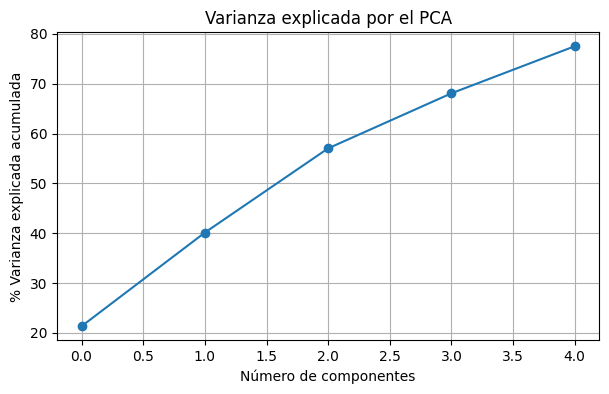

In [26]:
plt.figure(figsize=(7,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("% Varianza explicada acumulada")
plt.title("Varianza explicada por el PCA")
plt.grid(True)
plt.show()


In [27]:
pc1_importancia = pd.Series(abs(pca.components_[0]), index=X.columns)
pc1_importancia = pc1_importancia.sort_values(ascending=False)

print("Top variables que más influyen en PC1:")
print(pc1_importancia.head(10))


Top variables que más influyen en PC1:
Pclass         0.558771
Fare           0.537226
Age            0.366290
Embarked_Q     0.362678
Parch          0.246707
Sex_male       0.212514
SibSp          0.122715
Embarked_S     0.103160
PassengerId    0.041615
dtype: float64
